In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from dataset import PatchDataset
from models import PatchVAE, reparameterize

DATA_DIR = ROOT / "data" / "images"
VAE_CKPT = ROOT / "microlad-anode" / "vae_anode.pth"
PATCH_SIZE = 64
BATCH_SIZE = 2
SEED = 0

In [2]:
dataset = PatchDataset(DATA_DIR, patch_size=PATCH_SIZE, seed=SEED)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
batch = next(iter(loader))
batch.shape

torch.Size([2, 1, 64, 64])

In [3]:
vae = PatchVAE(latent_ch=4)
if VAE_CKPT.exists():
    ckpt = torch.load(VAE_CKPT, map_location="cpu")
    vae.load_state_dict(ckpt["vae"] if "vae" in ckpt else ckpt)
vae.eval()
with torch.no_grad():
    mu, logvar = vae.encode(batch * 2 - 1)
    z = reparameterize(mu, logvar)
    recon = vae.decode(z)

batch.shape, mu.shape, logvar.shape, z.shape, recon.shape

(torch.Size([2, 1, 64, 64]),
 torch.Size([2, 4, 16, 16]),
 torch.Size([2, 4, 16, 16]),
 torch.Size([2, 4, 16, 16]),
 torch.Size([2, 1, 64, 64]))

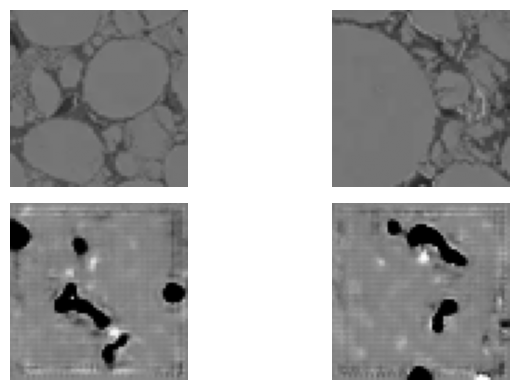

In [4]:
n = min(batch.shape[0], 4)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 4), squeeze=False)
for i in range(n):
    axes[0, i].imshow(batch[i].squeeze(0), cmap="gray", vmin=0, vmax=1)
    axes[1, i].imshow(recon[i].squeeze(0), cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")
    axes[1, i].axis("off")
plt.tight_layout()